In [1]:
import os
import sys

import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm

# Allow notebook to import from src/
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.signal_extractors.prediction_confidence import PredictionConfidenceExtractor
from src.signal_extractors.activation_signals import ActivationSignalExtractor
from src.signal_extractors.gradient_signals import GradientSignalExtractor
from src.signal_extractors.input_quality import InputQualityExtractor

from src.utils.neural_state_collector import NeuralStateCollector
from src.utils.reliability_dataset_generator import ReliabilityDatasetGenerator

In [2]:
# ============================================================
# Cell 2 - Load ResNet18 (CIFAR-10) and Test Dataset
# ============================================================

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using Device : {device}")

# ------------------------------------------------------------
# CIFAR-10 Test Dataset
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=True,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

print(f"Test Images : {len(test_dataset)}")

# ------------------------------------------------------------
# Load Trained ResNet18
# ------------------------------------------------------------

model = resnet18(num_classes=10)

checkpoint = "../models/resnet18_cifar10.pth"

model.load_state_dict(
    torch.load(
        checkpoint,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("ResNet18 Loaded Successfully!")

Using Device : mps
Test Images : 10000
ResNet18 Loaded Successfully!


In [4]:
# ============================================================
# Cell 3 - Initialize Reliability Framework
# ============================================================

from src.signal_extractors.prediction_confidence import PredictionConfidenceExtractor
from src.signal_extractors.activation_signals import ActivationSignalExtractor
from src.signal_extractors.gradient_signals import GradientSignalExtractor
from src.signal_extractors.input_quality import InputQualityExtractor

from src.utils.neural_state_collector import NeuralStateCollector
from src.utils.reliability_dataset_generator import ReliabilityDatasetGenerator

# ------------------------------------------------------------
# Select Target Layer
# (Last convolution layer of ResNet18)
# ------------------------------------------------------------

target_layer = model.layer4[-1]

collector = NeuralStateCollector(target_layer)
collector.register_hooks()

# ------------------------------------------------------------
# Initialize Extractors
# ------------------------------------------------------------

extractors = [

    PredictionConfidenceExtractor(),

    ActivationSignalExtractor(),

    GradientSignalExtractor(),

    InputQualityExtractor()

]

# ------------------------------------------------------------
# Dataset Generator
# ------------------------------------------------------------

generator = ReliabilityDatasetGenerator(extractors)

print("Framework Initialized Successfully!")
print(f"Loaded {len(extractors)} Reliability Extractors")

Framework Initialized Successfully!
Loaded 4 Reliability Extractors


In [6]:
# ============================================================
# Cell 4 - Generate Reliability Profile for ONE Image
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Get one sample
# ------------------------------------------------------------

images, labels = next(iter(test_loader))

images = images.to(device)

label = labels.item()

# ------------------------------------------------------------
# Forward pass through Neural State Collector
# ------------------------------------------------------------

states = collector.collect(model, images)

output = states["logits"]

prediction = states["prediction"].item()

print("=" * 60)
print("Prediction")
print("=" * 60)

print(f"Predicted Class : {prediction}")
print(f"True Label      : {label}")

# ------------------------------------------------------------
# Build sample dictionary
# ------------------------------------------------------------

sample = {

    "model": model,

    "input_tensor": images,

    "output": output,

    "activations": states["activations"],

    "gradients": states["gradients"],

    "image": (
        images.squeeze(0)
        .permute(1,2,0)
        .cpu()
        .numpy()
    ),

    "label": label
}

print("\nNeural State Successfully Collected!")

Prediction
Predicted Class : 3
True Label      : 3

Neural State Successfully Collected!


In [5]:
# ============================================================
# Cell 5 - Validate Every Extractor
# ============================================================

for extractor in extractors:

    print("=" * 70)

    print(extractor.name)

    print("=" * 70)

    signals = extractor.extract(**sample)

    for key, value in signals.items():

        print(f"{key:<35} : {value}")

    print()

Prediction Confidence Extractor
confidence                          : 0.9665142297744751
entropy                             : 0.19038239121437073
prediction_margin                   : 0.9460653066635132

Activation Signal Extractor
activation_mean                     : 1.1780929565429688
activation_std                      : 1.4291170835494995
activation_max                      : 7.38969612121582
activation_min                      : 0.0
activation_energy                   : 3.4262895584106445
activation_sparsity                 : 0.466796875
dead_neuron_ratio                   : 0.466796875
positive_activation_ratio           : 0.533203125
activation_entropy                  : 4.046950340270996

Gradient Signal Extractor
gradient_mean                       : -0.0034228917211294174
gradient_std                        : 0.031167130917310715
gradient_max                        : 0.07184997200965881
gradient_min                        : -0.13098099827766418
gradient_norm                

In [7]:
# ============================================================
# Cell 6 - Initialize Dataset Storage
# ============================================================

import pandas as pd
from tqdm import tqdm

dataset_rows = []

print("Dataset storage initialized.")

Dataset storage initialized.


In [8]:
# ============================================================
# Cell 7 - Generate Universal Reliability Dataset
# ============================================================

model.eval()

collector.register_hooks()

dataset_rows = []

# CIFAR-10 Normalization Parameters
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

for images, labels in tqdm(test_loader):

    # --------------------------------------------------------
    # Move normalized image to device (for the model)
    # --------------------------------------------------------

    images = images.to(device)

    label = labels.item()

    # --------------------------------------------------------
    # Collect Neural States
    # --------------------------------------------------------

    states = collector.collect(model, images)

    output = states["logits"]

    prediction = states["prediction"].item()

    # --------------------------------------------------------
    # Recover Original Image (Undo Normalization)
    # Used ONLY for Input Quality Features
    # --------------------------------------------------------

    original_image = images.squeeze(0).cpu().clone()

    original_image = original_image * std + mean

    original_image = torch.clamp(original_image, 0.0, 1.0)

    original_image = (
        original_image
        .permute(1, 2, 0)
        .numpy()
    )

    # --------------------------------------------------------
    # Build Sample Dictionary
    # --------------------------------------------------------

    sample = {

        "model": model,

        "input_tensor": images,

        "output": output,

        "activations": states["activations"],

        "gradients": states["gradients"],

        "image": original_image,

        "label": label

    }

    # --------------------------------------------------------
    # Extract Reliability Signals
    # --------------------------------------------------------

    row = {}

    for extractor in extractors:

        signals = extractor.extract(**sample)

        row.update(signals)

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------

    row["prediction"] = prediction

    row["true_label"] = label

    row["failure_label"] = int(prediction != label)

    dataset_rows.append(row)

collector.remove_hooks()

print("\n========================================")
print("Dataset Generation Complete")
print("========================================")
print(f"Total Samples : {len(dataset_rows)}")

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 11/10000 [00:00<03:21, 49.64it/s]


========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 31
Max Pixel  : 253

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 0
Max Pixel  : 239

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 4
Max Pixel  : 250

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 34
Max Pixel  : 218

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 9
Max Pixel  : 212

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 8
Max Pixel  : 185

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 2
Max Pixel  : 248

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 23
Max Pixel  : 254

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtyp

  0%|          | 23/10000 [00:00<03:08, 53.00it/s]


========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 10
Max Pixel  : 199

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 0
Max Pixel  : 254

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 0
Max Pixel  : 251

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 7
Max Pixel  : 250

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 1
Max Pixel  : 254

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 30
Max Pixel  : 225

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 3
Max Pixel  : 253

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 30
Max Pixel  : 247

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtyp

...


========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 20
Max Pixel  : 250

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 17
Max Pixel  : 244

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 6
Max Pixel  : 236

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 0
Max Pixel  : 230

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 42
Max Pixel  : 246

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 14
Max Pixel  : 239

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 22
Max Pixel  : 225

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 27
Max Pixel  : 209

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
D

100%|█████████▉| 9993/10000 [01:51<00:00, 86.75it/s]


========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 6
Max Pixel  : 190

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 6
Max Pixel  : 235

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 12
Max Pixel  : 241

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 24
Max Pixel  : 219

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 4
Max Pixel  : 243

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 4
Max Pixel  : 250

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 2
Max Pixel  : 234

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype      : uint8
Min Pixel  : 6
Max Pixel  : 254

========== INPUT QUALITY DEBUG ==========
Shape      : (32, 32)
Dtype

100%|██████████| 10000/10000 [01:51<00:00, 89.64it/s]


Dataset Generation Complete
Total Samples : 10000


In [9]:
# ============================================================
# Cell 8 - Create DataFrame
# ============================================================

df = pd.DataFrame(dataset_rows)

print(df.shape)

df.head()

(10000, 29)


,confidence,entropy,prediction_margin,activation_mean,activation_std,activation_max,activation_min,activation_energy,activation_sparsity,dead_neuron_ratio,...,gradient_entropy,brightness,contrast,image_entropy,blur_score,laplacian_variance,edge_density,prediction,true_label,failure_label
0,0.693736,1.112976,0.558915,0.370606,0.489552,3.145806,0.0,0.376542,0.298828,0.298828,...,6.238230,109.325195,37.991939,6.897243,3172.214844,3172.214844,0.274414,3,3,0
1,0.684337,0.868562,0.466290,1.074382,1.307902,6.743713,0.0,2.861562,0.423828,0.423828,...,6.238141,153.391602,78.194906,7.021043,2469.134766,2469.134766,0.251953,8,8,0
2,0.825382,0.580671,0.679395,0.695826,0.833168,4.562689,0.0,1.176987,0.410156,0.410156,...,6.238141,130.231445,64.558447,7.620032,1568.395752,1568.395752,0.218750,8,8,0
3,0.971878,0.170356,0.960077,0.510351,0.751364,3.695982,0.0,0.823904,0.347656,0.347656,...,6.238200,151.815430,53.454494,6.914163,2037.458252,2037.458252,0.198242,0,0,0
4,0.759581,0.774034,0.632923,0.608280,0.922197,4.602489,0.0,1.218791,0.277344,0.277344,...,6.238155,113.909180,39.379892,7.164474,3411.849121,3411.849121,0.316406,6,6,0


In [10]:
# ============================================================
# Cell 9 - Save Reliability Dataset
# ============================================================

save_path = "../features/reliability_dataset_v1.csv"

df.to_csv(save_path, index=False)

print(f"Dataset saved to:\n{save_path}")

Dataset saved to:
../features/reliability_dataset_v1.csv


In [11]:
print(df["failure_label"].value_counts())

failure_label
0    7131
1    2869
Name: count, dtype: int64


In [10]:
df.shape

(10000, 29)

In [11]:
df.columns.tolist()

['confidence',
 'entropy',
 'prediction_margin',
 'activation_mean',
 'activation_std',
 'activation_max',
 'activation_min',
 'activation_energy',
 'activation_sparsity',
 'dead_neuron_ratio',
 'positive_activation_ratio',
 'activation_entropy',
 'gradient_mean',
 'gradient_std',
 'gradient_max',
 'gradient_min',
 'gradient_norm',
 'gradient_energy',
 'gradient_sparsity',
 'gradient_entropy',
 'brightness',
 'contrast',
 'image_entropy',
 'blur_score',
 'laplacian_variance',
 'edge_density',
 'prediction',
 'true_label',
 'failure_label']

In [12]:
df["failure_label"].value_counts()

failure_label
1    8823
0    1177
Name: count, dtype: int64

In [13]:
df.describe()

,confidence,entropy,prediction_margin,activation_mean,activation_std,activation_max,activation_min,activation_energy,activation_sparsity,dead_neuron_ratio,...,gradient_entropy,brightness,contrast,image_entropy,blur_score,laplacian_variance,edge_density,prediction,true_label,failure_label
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.810542,0.661620,0.717138,0.863362,1.073762,5.486306,0.0,2.420219,0.428430,0.428430,...,6.238145,122.909380,49.976747,6.945300,2410.902539,2410.902539,0.216373,7.666600,4.500000,0.882300
std,0.176369,0.462432,0.256195,0.480113,0.542432,2.037028,0.0,2.706426,0.041020,0.041020,...,0.000016,31.208175,15.362128,0.592928,1418.226774,1418.226774,0.067001,1.344331,2.872425,0.322269
min,0.208639,0.015649,0.000288,0.282081,0.340007,1.750545,0.0,0.204955,0.251953,0.251953,...,6.238141,16.518555,7.711819,1.597133,81.817810,81.817810,0.000000,0.000000,0.000000,0.000000
25%,0.730663,0.279837,0.601210,0.479434,0.655487,3.910979,0.0,0.653550,0.402344,0.402344,...,6.238141,102.557373,38.808664,6.742908,1404.266449,1404.266449,0.169922,8.000000,2.000000,1.000000
50%,0.876159,0.550690,0.814031,0.734699,0.898772,5.178371,0.0,1.346607,0.437500,0.437500,...,6.238141,121.373047,49.701825,7.090955,2139.926147,2139.926147,0.220215,8.000000,4.500000,1.000000
75%,0.943743,0.969642,0.908159,1.113205,1.327808,6.687863,0.0,3.000725,0.458984,0.458984,...,6.238141,141.199219,60.519366,7.328799,3101.729675,3101.729675,0.265625,8.000000,7.000000,1.000000
max,0.997878,2.012632,0.995852,3.007046,3.647047,14.257757,0.0,22.317299,0.513672,0.513672,...,6.238230,251.953125,106.666351,7.749659,15906.315430,15906.315430,0.397461,8.000000,9.000000,1.000000


In [14]:
# Dataset Information
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Shape :", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\n")

# Missing values
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(df.isnull().sum())

print("\n")

# Statistics
print("=" * 60)
print("STATISTICS")
print("=" * 60)

display(df.describe())

print("\n")

# Failure Distribution
print("=" * 60)
print("FAILURE LABEL DISTRIBUTION")
print("=" * 60)

print(df["failure_label"].value_counts())

print("\n")

print(df["failure_label"].value_counts(normalize=True))

DATASET INFORMATION
Shape : (10000, 29)

Columns:
['confidence', 'entropy', 'prediction_margin', 'activation_mean', 'activation_std', 'activation_max', 'activation_min', 'activation_energy', 'activation_sparsity', 'dead_neuron_ratio', 'positive_activation_ratio', 'activation_entropy', 'gradient_mean', 'gradient_std', 'gradient_max', 'gradient_min', 'gradient_norm', 'gradient_energy', 'gradient_sparsity', 'gradient_entropy', 'brightness', 'contrast', 'image_entropy', 'blur_score', 'laplacian_variance', 'edge_density', 'prediction', 'true_label', 'failure_label']


MISSING VALUES
confidence                   0
entropy                      0
prediction_margin            0
activation_mean              0
activation_std               0
activation_max               0
activation_min               0
activation_energy            0
activation_sparsity          0
dead_neuron_ratio            0
positive_activation_ratio    0
activation_entropy           0
gradient_mean                0
gradient_std

,confidence,entropy,prediction_margin,activation_mean,activation_std,activation_max,activation_min,activation_energy,activation_sparsity,dead_neuron_ratio,...,gradient_entropy,brightness,contrast,image_entropy,blur_score,laplacian_variance,edge_density,prediction,true_label,failure_label
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.810542,0.661620,0.717138,0.863362,1.073762,5.486306,0.0,2.420219,0.428430,0.428430,...,6.238145,122.909380,49.976747,6.945300,2410.902539,2410.902539,0.216373,7.666600,4.500000,0.882300
std,0.176369,0.462432,0.256195,0.480113,0.542432,2.037028,0.0,2.706426,0.041020,0.041020,...,0.000016,31.208175,15.362128,0.592928,1418.226774,1418.226774,0.067001,1.344331,2.872425,0.322269
min,0.208639,0.015649,0.000288,0.282081,0.340007,1.750545,0.0,0.204955,0.251953,0.251953,...,6.238141,16.518555,7.711819,1.597133,81.817810,81.817810,0.000000,0.000000,0.000000,0.000000
25%,0.730663,0.279837,0.601210,0.479434,0.655487,3.910979,0.0,0.653550,0.402344,0.402344,...,6.238141,102.557373,38.808664,6.742908,1404.266449,1404.266449,0.169922,8.000000,2.000000,1.000000
50%,0.876159,0.550690,0.814031,0.734699,0.898772,5.178371,0.0,1.346607,0.437500,0.437500,...,6.238141,121.373047,49.701825,7.090955,2139.926147,2139.926147,0.220215,8.000000,4.500000,1.000000
75%,0.943743,0.969642,0.908159,1.113205,1.327808,6.687863,0.0,3.000725,0.458984,0.458984,...,6.238141,141.199219,60.519366,7.328799,3101.729675,3101.729675,0.265625,8.000000,7.000000,1.000000
max,0.997878,2.012632,0.995852,3.007046,3.647047,14.257757,0.0,22.317299,0.513672,0.513672,...,6.238230,251.953125,106.666351,7.749659,15906.315430,15906.315430,0.397461,8.000000,9.000000,1.000000




FAILURE LABEL DISTRIBUTION
failure_label
1    8823
0    1177
Name: count, dtype: int64


failure_label
1    0.8823
0    0.1177
Name: proportion, dtype: float64


In [3]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("=" * 50)
print(f"Correct : {correct}")
print(f"Total   : {total}")
print(f"Accuracy: {accuracy:.4f}")
print("=" * 50)

Correct : 7131
Total   : 10000
Accuracy: 0.7131


In [12]:
# ============================================================
# Cell 10 - EDA Imports
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import mutual_info_classif

plt.style.use("default")

print("EDA Libraries Loaded Successfully")

EDA Libraries Loaded Successfully


In [13]:
# ============================================================
# Cell 11 - Dataset Overview
# ============================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Shape: {df.shape}")

print("\n")

print(df.info())

print("\n")

print(df.describe())

print("\n")

print("=" * 60)
print("Failure Distribution")
print("=" * 60)

display(df["failure_label"].value_counts())

display(
    df["failure_label"].value_counts(normalize=True)
)

DATASET OVERVIEW
Shape: (10000, 29)


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   confidence                 10000 non-null  float64
 1   entropy                    10000 non-null  float64
 2   prediction_margin          10000 non-null  float64
 3   activation_mean            10000 non-null  float64
 4   activation_std             10000 non-null  float64
 5   activation_max             10000 non-null  float64
 6   activation_min             10000 non-null  float64
 7   activation_energy          10000 non-null  float64
 8   activation_sparsity        10000 non-null  float64
 9   dead_neuron_ratio          10000 non-null  float64
 10  positive_activation_ratio  10000 non-null  float64
 11  activation_entropy         10000 non-null  float64
 12  gradient_mean              10000 non-null  float64
 13  gradient_std        

failure_label
0    7131
1    2869
Name: count, dtype: int64

failure_label
0    0.7131
1    0.2869
Name: proportion, dtype: float64

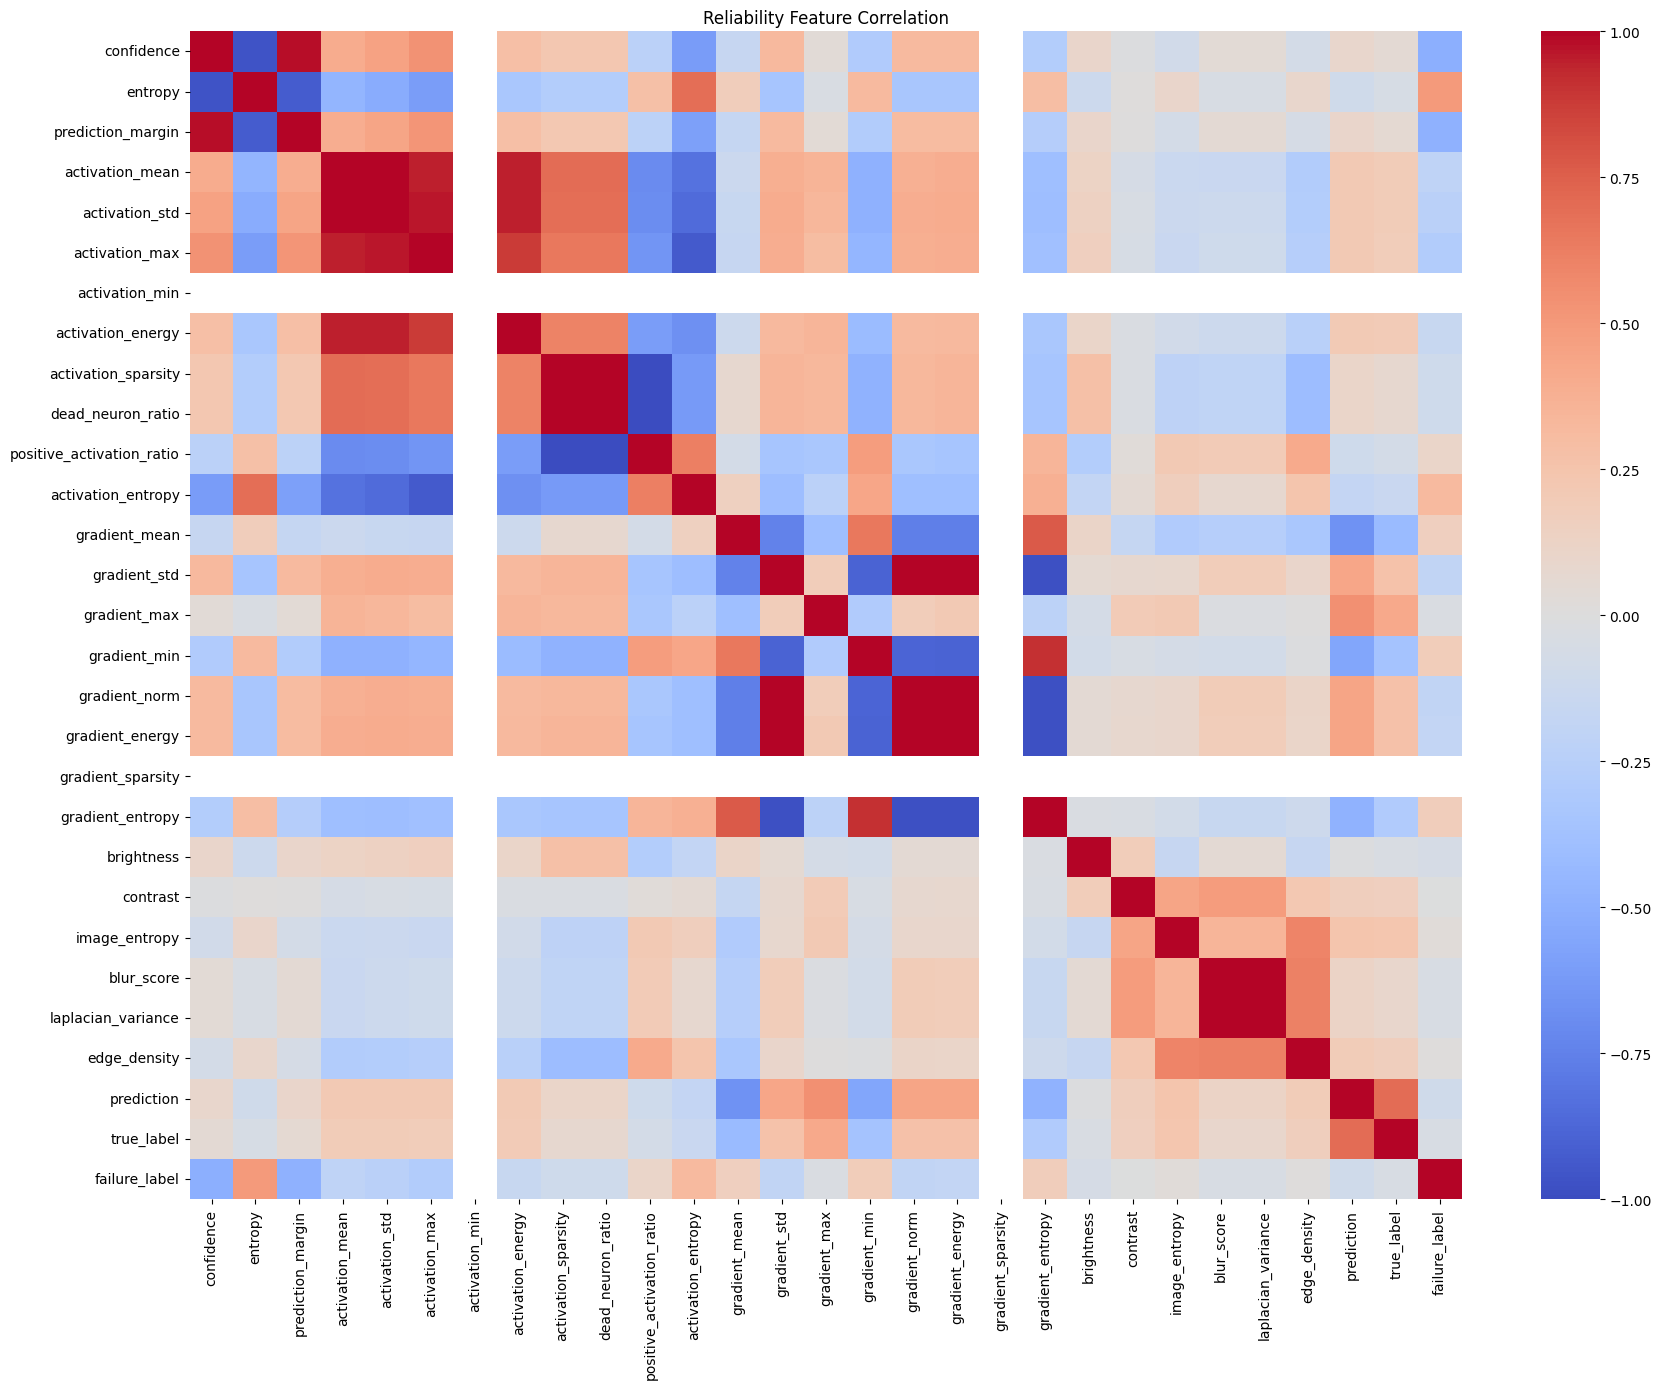

In [14]:
# ============================================================
# Cell 12 - Correlation Heatmap
# ============================================================

plt.figure(figsize=(18,14))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Reliability Feature Correlation")

plt.tight_layout()

plt.savefig("../results/eda/correlation_heatmap.png", dpi=300)

plt.show()

In [15]:
# ============================================================
# Cell 13 - Failure vs Correct Feature Comparison
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../results/eda/boxplots", exist_ok=True)

feature_columns = [
    col for col in df.columns
    if col not in ["prediction", "true_label", "failure_label"]
]

for feature in feature_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="failure_label",
        y=feature
    )

    plt.title(feature)

    plt.xlabel("Failure Label")
    plt.ylabel(feature)

    plt.tight_layout()

    plt.savefig(
        f"../results/eda/boxplots/{feature}.png",
        dpi=300
    )

    plt.close()

print(f"Generated {len(feature_columns)} boxplots.")

Generated 26 boxplots.


In [16]:
# ============================================================
# Cell 14 - Mutual Information Feature Ranking
# ============================================================

from sklearn.feature_selection import mutual_info_classif

feature_columns = [
    c for c in df.columns
    if c not in [
        "prediction",
        "true_label",
        "failure_label"
    ]
]

X = df[feature_columns]

y = df["failure_label"]

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

importance_df = (
    pd.DataFrame({
        "Feature": feature_columns,
        "Mutual Information": mi_scores
    })
    .sort_values(
        "Mutual Information",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df

,Feature,Mutual Information
0,confidence,0.144504
1,entropy,0.138600
2,prediction_margin,0.136908
3,activation_energy,0.084994
4,activation_std,0.080784
5,activation_entropy,0.080760
6,activation_max,0.080495
7,activation_mean,0.080212
8,activation_sparsity,0.039293
9,gradient_entropy,0.031747


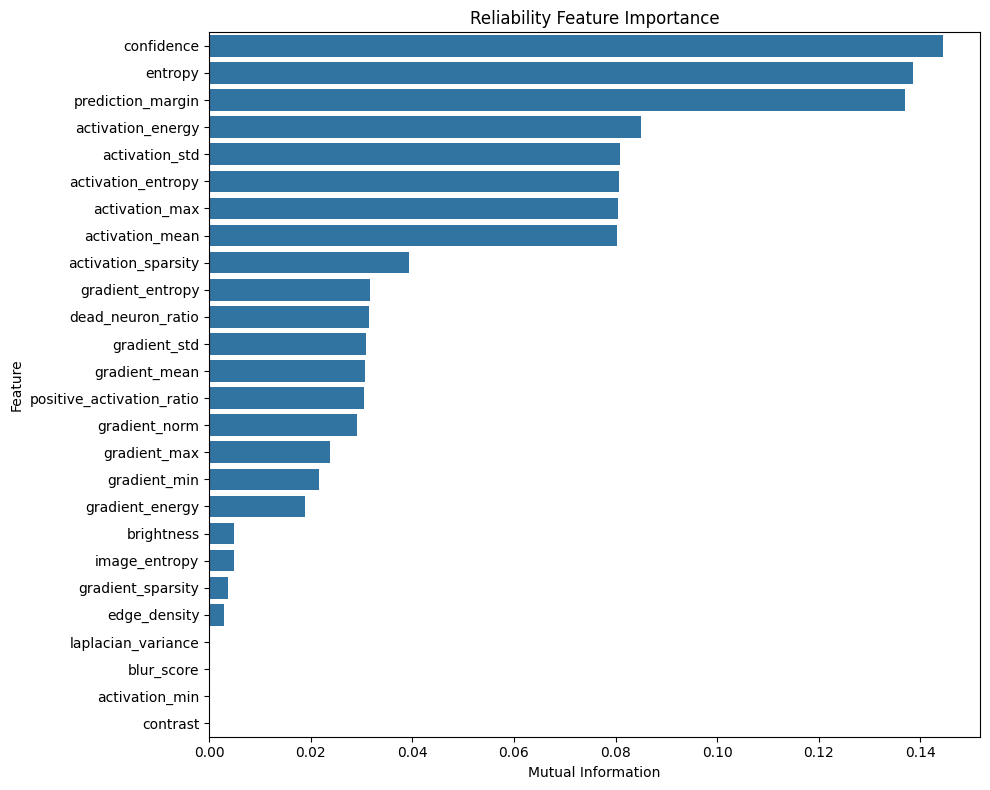

In [17]:
# ============================================================
# Cell 15 - Mutual Information Plot
# ============================================================

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_df,
    x="Mutual Information",
    y="Feature"
)

plt.title("Reliability Feature Importance")

plt.tight_layout()

plt.savefig(
    "../results/eda/mutual_information.png",
    dpi=300
)

plt.show()

In [18]:
# ============================================================
# Cell 16 - Confidence Threshold Baseline
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

thresholds = np.arange(0.05, 1.00, 0.01)

results = []

y_true = df["failure_label"]

for threshold in thresholds:

    # Predict failure if confidence is below threshold
    y_pred = (df["confidence"] < threshold).astype(int)

    results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(y_true, y_pred),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_true,
            y_pred
        )

    })

baseline_df = pd.DataFrame(results)

baseline_df.head()

,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.05,0.7131,0.0,0.0,0.0,0.5
1,0.06,0.7131,0.0,0.0,0.0,0.5
2,0.07,0.7131,0.0,0.0,0.0,0.5
3,0.08,0.7131,0.0,0.0,0.0,0.5
4,0.09,0.7131,0.0,0.0,0.0,0.5


In [19]:
# ============================================================
# Cell 17 - Best Confidence Threshold
# ============================================================

best = baseline_df.sort_values(
    "F1",
    ascending=False
).iloc[0]

print("=" * 60)
print("BEST CONFIDENCE BASELINE")
print("=" * 60)

display(best)

BEST CONFIDENCE BASELINE


Threshold    0.750000
Accuracy     0.717200
Precision    0.504383
Recall       0.822238
F1           0.625232
ROC_AUC      0.748589
Name: 70, dtype: float64

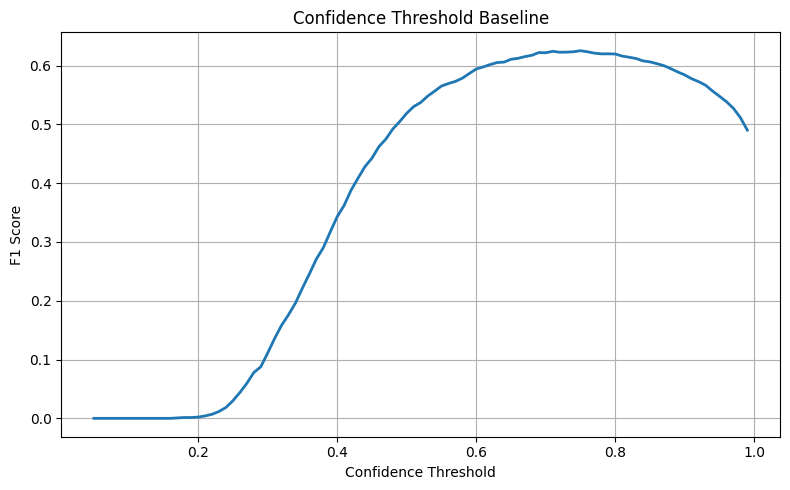

In [20]:
# ============================================================
# Cell 18 - Confidence Threshold Performance
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    baseline_df["Threshold"],
    baseline_df["F1"],
    linewidth=2
)

plt.xlabel("Confidence Threshold")

plt.ylabel("F1 Score")

plt.title("Confidence Threshold Baseline")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../results/eda/confidence_threshold_curve.png",
    dpi=300
)

plt.show()

              precision    recall  f1-score   support

           0       0.90      0.67      0.77      7131
           1       0.50      0.82      0.63      2869

    accuracy                           0.72     10000
   macro avg       0.70      0.75      0.70     10000
weighted avg       0.79      0.72      0.73     10000



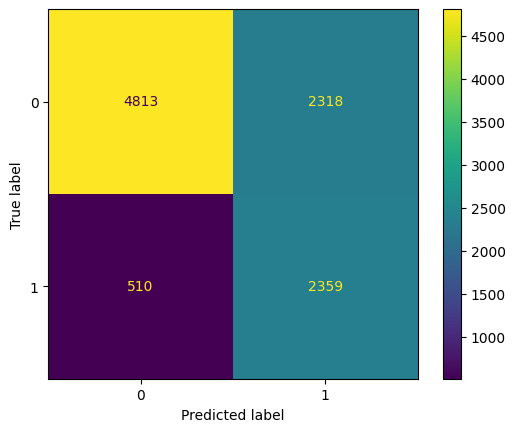

In [21]:
# ============================================================
# Cell 19 - Evaluate Best Threshold
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

best_threshold = best["Threshold"]

y_pred = (
    df["confidence"] < best_threshold
).astype(int)

print(classification_report(
    y_true,
    y_pred
))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred
)

plt.show()

In [22]:
# ============================================================
# Cell 20 - Prepare Training Data
# ============================================================

from sklearn.model_selection import train_test_split

# Features
feature_columns = [
    c for c in df.columns
    if c not in [
        "prediction",
        "true_label",
        "failure_label"
    ]
]

X = df[feature_columns]

y = df["failure_label"]

print("Features:", len(feature_columns))
print("Samples :", len(X))

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Features: 26
Samples : 10000

Training Samples : 8000
Testing Samples  : 2000


In [27]:
# ============================================================
# Cell 21 - Train Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest Training Complete!")

Random Forest Training Complete!


Best Threshold : 0.39
Best F1        : 0.6350
RANDOM FOREST RESULTS
Accuracy : 0.7235
Precision: 0.5112
Recall   : 0.8380
F1 Score : 0.6350
ROC-AUC  : 0.8265


              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1426
           1       0.51      0.84      0.63       574

    accuracy                           0.72      2000
   macro avg       0.71      0.76      0.71      2000
weighted avg       0.80      0.72      0.74      2000



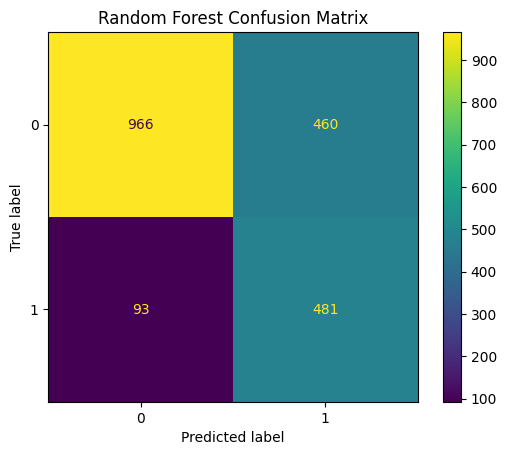

In [28]:
# ============================================================
# Cell 22 - Evaluate Random Forest
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

rf_prob = rf.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.95, 0.01)

best_f1 = 0
best_threshold = 0.5

for threshold in thresholds:

    preds = (rf_prob >= threshold).astype(int)

    score = f1_score(y_test, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print(f"Best Threshold : {best_threshold:.2f}")
print(f"Best F1        : {best_f1:.4f}")

rf_pred = (rf_prob >= best_threshold).astype(int)

rf_prob = rf.predict_proba(X_test)[:,1]

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall   : {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_prob):.4f}")

print("\n")

print(classification_report(
    y_test,
    rf_pred
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest Confusion Matrix")

plt.show()

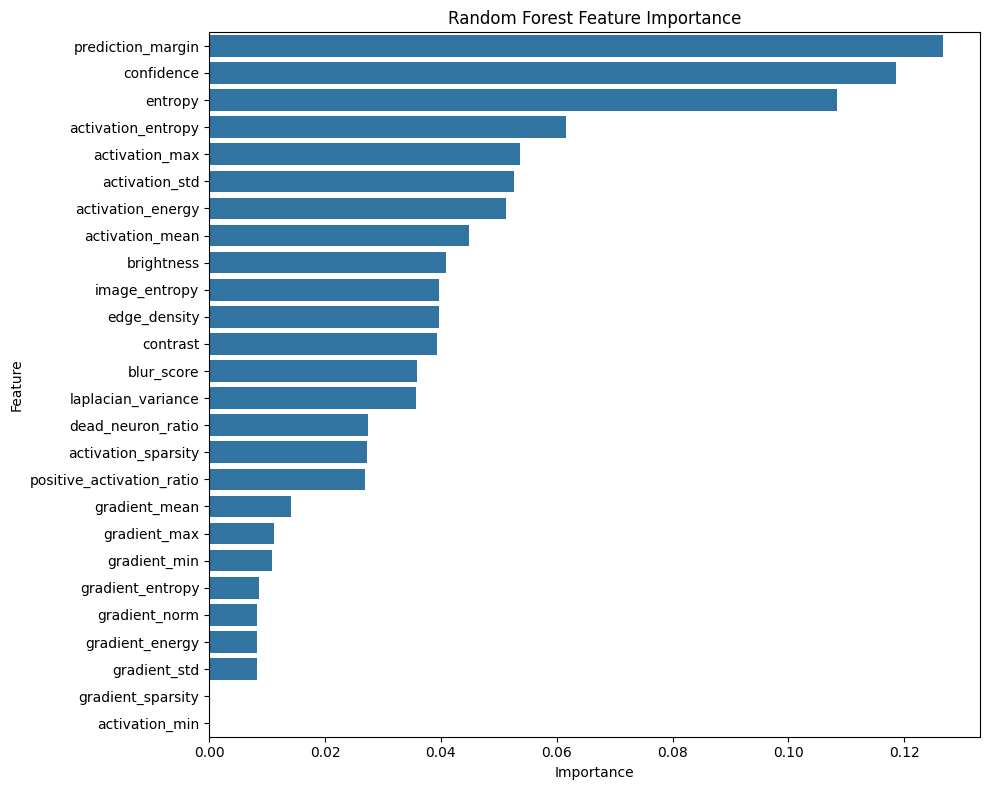

,Feature,Importance
2,prediction_margin,0.126742
0,confidence,0.118507
1,entropy,0.108469
11,activation_entropy,0.061641
5,activation_max,0.053708
4,activation_std,0.052555
7,activation_energy,0.051248
3,activation_mean,0.044866
20,brightness,0.040833
22,image_entropy,0.039662


In [29]:
# ============================================================
# Cell 23 - Random Forest Feature Importance
# ============================================================

importance = pd.DataFrame({

    "Feature": feature_columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    "../results/eda/random_forest_importance.png",
    dpi=300
)

plt.show()

importance.head(15)

In [30]:
# ============================================================
# Cell 24 - Baseline vs Random Forest
# ============================================================

comparison = pd.DataFrame({

    "Model":[
        "Confidence Threshold",
        "Random Forest"
    ],

    "Accuracy":[
        best["Accuracy"],
        accuracy_score(y_test, rf_pred)
    ],

    "Precision":[
        best["Precision"],
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        best["Recall"],
        recall_score(y_test, rf_pred)
    ],

    "F1":[
        best["F1"],
        f1_score(y_test, rf_pred)
    ],

    "ROC_AUC":[
        best["ROC_AUC"],
        roc_auc_score(y_test, rf_prob)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Confidence Threshold,0.7172,0.504383,0.822238,0.625232,0.748589
1,Random Forest,0.7235,0.511158,0.837979,0.634983,0.826478
